# Principal Component Analysis (PCA) 

It is a fundamental and widely used technique in machine learning, primarily for dimensionality reduction. Here's a breakdown of its key aspects:  

What is PCA?

    PCA is a statistical procedure that transforms a set of correlated variables into a set of linearly uncorrelated variables called principal components.   

Essentially, it aims to find the directions (principal components) along which the data varies the most.  
These principal components are ordered, with the first component capturing the maximum variance, the second capturing the second most, and so on.  
By selecting a subset of these principal components, you can reduce the dimensionality of your data while retaining as much of the original information as possible.  

Why is PCA Important?

    Dimensionality Reduction:
        High-dimensional data can lead to the "curse of dimensionality," where models become complex, computationally expensive, and prone to overfitting. PCA helps mitigate this.   

It simplifies data, making it easier to analyze and visualize.  

Feature Extraction:

    PCA can identify the most significant features (principal components) that contribute to the variance in the data.   

This can help in feature selection and improve model performance.  

Noise Reduction:

    By focusing on the principal components that capture the most variance, PCA can effectively filter out noise in the data.   

Data Visualization:

    PCA can reduce high-dimensional data to 2D or 3D, making it possible to visualize and explore complex datasets. 1 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

In [4]:
cancer = load_breast_cancer()

In [7]:
print("details of cancer dataset " , cancer['DESCR'])

details of cancer dataset  .. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 

In [12]:
#import dataset , create dataset from cancer array

df =pd.DataFrame(cancer['data'], columns= cancer['feature_names'])

In [13]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [14]:
#implement PCA we need to change scale of the data 

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA



In [15]:
#split data into train , test dataset

X_train, X_test =train_test_split(df,test_size=0.2, random_state=42)

#use standard scaler to fit and transform dataset

sc= StandardScaler()

sc.fit(X_train)

X_train_std =sc.transform(X_train)

X_test_std = sc.transform(X_test)

In [23]:
len(exp_var_pca)

30

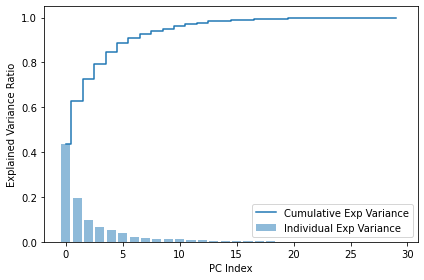

In [18]:
#apply PCA on training dataset 

pca = PCA()

X_train_pca = pca.fit_transform(X_train_std)

exp_var_pca = pca.explained_variance_ratio_

cum_sum_eignvalues =np.cumsum(exp_var_pca)


plt.bar(range(0,len(exp_var_pca)),exp_var_pca,alpha =0.5 , align='center' , label = 'Individual Exp Variance')

plt.step(range(0,len(cum_sum_eignvalues)),cum_sum_eignvalues,where='mid' ,label='Cumulative Exp Variance')

plt.ylabel('Explained Variance Ratio')

plt.xlabel('PC Index')
plt.legend(loc='best')

plt.tight_layout()
plt.show()

In [19]:
pca.components_

array([[ 2.16014846e-01,  1.01699596e-01,  2.25181465e-01,
         2.18534830e-01,  1.48981569e-01,  2.40835871e-01,
         2.59499690e-01,  2.63324252e-01,  1.46217348e-01,
         6.57406649e-02,  2.03918546e-01,  2.34543987e-02,
         2.09023919e-01,  1.99502970e-01,  2.15718507e-02,
         1.65762530e-01,  1.49054410e-01,  1.82429814e-01,
         4.76642673e-02,  9.87533276e-02,  2.26391948e-01,
         1.05122879e-01,  2.36126297e-01,  2.24215789e-01,
         1.32347855e-01,  2.11297039e-01,  2.29556005e-01,
         2.52917161e-01,  1.27240897e-01,  1.32340793e-01],
       [-2.40040164e-01, -5.12630139e-02, -2.22160786e-01,
        -2.36489281e-01,  1.69316336e-01,  1.50134402e-01,
         6.40373456e-02, -3.96395631e-02,  1.83279546e-01,
         3.61447295e-01, -1.08859253e-01,  9.69510543e-02,
        -9.16036710e-02, -1.53645976e-01,  1.94465623e-01,
         2.37907034e-01,  2.07841771e-01,  1.43048104e-01,
         1.74509277e-01,  2.81101891e-01, -2.24547535e-